<a href="https://colab.research.google.com/github/Martinnon/testrepo/blob/main/code/1_data_wrangling_tidyverse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tidyverse en Colab


## Objetivos de aprendizaje
Al finalizar, deberías poder:
1. leer datos con `readr`
2. manipular tablas con `dplyr`
3. unir tablas con `joins`
4. reorganizar datos con `tidyr`
5. manejar valores perdidos
6. combinar tablas por filas y columnas

## Antes de comenzar
Ejecuta las celdas en orden, de arriba hacia abajo.

Las celdas con `%%R` ejecutan código R en Colab.

# 1. Preparación de Colab

In [ ]:
!apt-get -qq update
!apt-get -qq install -y r-base r-base-dev
!pip -q install rpy2
%load_ext rpy2.ipython

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [ ]:
%%R
install_if_missing <- function(pkgs) {
  to_install <- pkgs[!pkgs %in% installed.packages()[, "Package"]]
  if (length(to_install) > 0) {
    install.packages(to_install, repos = "https://cloud.r-project.org")
  }
}

install_if_missing(c("tidyverse", "nycflights13"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/nycflights13_1.0.2.tar.gz'
Content type 'application/x-gzip' length 4504033 bytes (4.3 MB)
downloaded 4.3 MB


The downloaded source packages are in
	‘/tmp/RtmpLtrNjr/downloaded_packages’


In [ ]:
%%R
library(tidyverse)
library(nycflights13)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


# 2. Primera vista a los datos

Usaremos el dataset `flights`.

## exploracion básica
Antes de analizar datos, hay que mirar:
- columnas
- tipos de datos
- primeras filas

In [ ]:
%%R
glimpse(flights)

Rows: 336,776
Columns: 19
$ year           <int> 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2013, 2…
$ month          <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ day            <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1…
$ dep_time       <int> 517, 533, 542, 544, 554, 554, 555, 557, 557, 558, 558, …
$ sched_dep_time <int> 515, 529, 540, 545, 600, 558, 600, 600, 600, 600, 600, …
$ dep_delay      <dbl> 2, 4, 2, -1, -6, -4, -5, -3, -3, -2, -2, -2, -2, -2, -1…
$ arr_time       <int> 830, 850, 923, 1004, 812, 740, 913, 709, 838, 753, 849,…
$ sched_arr_time <int> 819, 830, 850, 1022, 837, 728, 854, 723, 846, 745, 851,…
$ arr_delay      <dbl> 11, 20, 33, -18, -25, 12, 19, -14, -8, 8, -2, -3, 7, -1…
$ carrier        <chr> "UA", "UA", "AA", "B6", "DL", "UA", "B6", "EV", "B6", "…
$ flight         <int> 1545, 1714, 1141, 725, 461, 1696, 507, 5708, 79, 301, 4…
$ tailnum        <chr> "N14228", "N24211", "N619AA", "N804JB", "N668DN", "N394…
$ origin      

In [ ]:
%%R
flights %>% slice_head(n = 8)

# A tibble: 8 × 19
   year month   day dep_time sched_dep_time dep_delay arr_time sched_arr_time
  <int> <int> <int>    <int>          <int>     <dbl>    <int>          <int>
1  2013     1     1      517            515         2      830            819
2  2013     1     1      533            529         4      850            830
3  2013     1     1      542            540         2      923            850
4  2013     1     1      544            545        -1     1004           1022
5  2013     1     1      554            600        -6      812            837
6  2013     1     1      554            558        -4      740            728
7  2013     1     1      555            600        -5      913            854
8  2013     1     1      557            600        -3      709            723
# ℹ 11 more variables: arr_delay <dbl>, carrier <chr>, flight <int>,
#   tailnum <chr>, origin <chr>, dest <chr>, air_time <dbl>, distance <dbl>,
#   hour <dbl>, minute <dbl>, time_hour <dttm>


In [ ]:
%%R
dim(flights)

[1] 336776     19



### Ejercicio rápido
¿Cuantas filas y columnas (variables) tiene el data.frame?

¿Cuales son los tipos de variables?


# 3. Leer datos con `readr`

`readr` permite leer archivos como CSV o tabular de forma simple.

In [ ]:
%%R
texto_csv <- "id,nombre,edad
1,Ana,21
2,Luis,24
3,Sofía,22
4,Tomás,23"

writeLines(texto_csv, "personas.csv")

personas <- readr::read_csv("personas.csv", show_col_types = FALSE)
personas

# A tibble: 4 × 3
     id nombre  edad
  <dbl> <chr>  <dbl>
1     1 Ana       21
2     2 Luis      24
3     3 Sofía     22
4     4 Tomás     23


## Observa
- `read_csv()` detecta tipos automáticamente
- el resultado es un `tibble`

### Ejercicio básico
Crea y lee un archivo `cursos.csv` con columnas:
- `id`
- `curso`
- `seccion`

In [ ]:
%%R
# Escribe aquí tu respuesta

# 4. Seleccionar columnas con `select()`

`select()` sirve para elegir ciertas columnas.

In [ ]:
%%R
flights %>%
  select(year, carrier, origin, dest)


# A tibble: 336,776 × 4
    year carrier origin dest 
   <int> <chr>   <chr>  <chr>
 1  2013 UA      EWR    IAH  
 2  2013 UA      LGA    IAH  
 3  2013 AA      JFK    MIA  
 4  2013 B6      JFK    BQN  
 5  2013 DL      LGA    ATL  
 6  2013 UA      EWR    ORD  
 7  2013 B6      EWR    FLL  
 8  2013 EV      LGA    IAD  
 9  2013 B6      JFK    MCO  
10  2013 AA      LGA    ORD  
# ℹ 336,766 more rows
# ℹ Use `print(n = ...)` to see more rows


### Ejercicio básico
Selecciona:
- `carrier`
- `flight`
- `dest`

In [ ]:
%%R
# Tu respuesta
flights %>%
  select(flight, carrier, dest)  %>% slice_head(n = 10)

# A tibble: 10 × 3
   flight carrier dest 
    <int> <chr>   <chr>
 1   1545 UA      IAH  
 2   1714 UA      IAH  
 3   1141 AA      MIA  
 4    725 B6      BQN  
 5    461 DL      ATL  
 6   1696 UA      ORD  
 7    507 B6      FLL  
 8   5708 EV      IAD  
 9     79 B6      MCO  
10    301 AA      ORD  


In [ ]:
%%R
#glimpse(flights)
#head(flights)

flights %>% select(carrier:distance)

# A tibble: 336,776 × 7
   carrier flight tailnum origin dest  air_time distance
   <chr>    <int> <chr>   <chr>  <chr>    <dbl>    <dbl>
 1 UA        1545 N14228  EWR    IAH        227     1400
 2 UA        1714 N24211  LGA    IAH        227     1416
 3 AA        1141 N619AA  JFK    MIA        160     1089
 4 B6         725 N804JB  JFK    BQN        183     1576
 5 DL         461 N668DN  LGA    ATL        116      762
 6 UA        1696 N39463  EWR    ORD        150      719
 7 B6         507 N516JB  EWR    FLL        158     1065
 8 EV        5708 N829AS  LGA    IAD         53      229
 9 B6          79 N593JB  JFK    MCO        140      944
10 AA         301 N3ALAA  LGA    ORD        138      733
# ℹ 336,766 more rows
# ℹ Use `print(n = ...)` to see more rows


# 5. Filtrar filas con `filter()`

`filter()` sirve para filtrar filas que cumplen una condición.

In [ ]:
%%R
flights %>%
  filter(dest == "LAX") %>%
  select(carrier, flight, origin, dest) %>%
  slice_head(n = 10)

# A tibble: 10 × 4
   carrier flight origin dest 
   <chr>    <int> <chr>  <chr>
 1 UA         194 JFK    LAX  
 2 UA        1665 EWR    LAX  
 3 VX         399 JFK    LAX  
 4 B6         671 JFK    LAX  
 5 AA          33 JFK    LAX  
 6 UA        1506 EWR    LAX  
 7 UA         443 JFK    LAX  
 8 AA           1 JFK    LAX  
 9 VX         407 JFK    LAX  
10 DL         120 JFK    LAX  


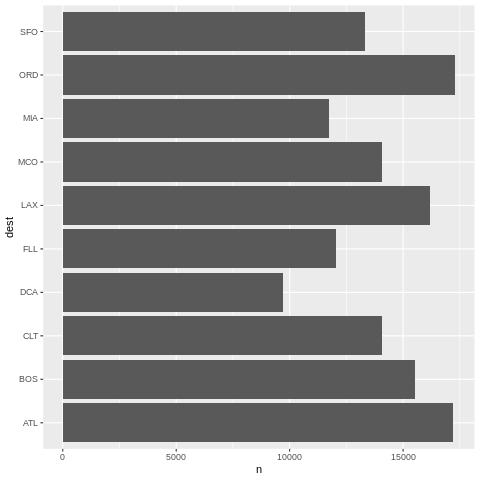

In [ ]:
%%R

#sort(table(flights$dest))
hd=flights %>% select(dest) %>%
           group_by(dest) %>%
           summarise(n = n()) %>%
           arrange(desc(n))

#flights %>% select(dest) %>%
#  ggplot(aes(y=dest)) +
#  geom_bar()

hd %>% slice_head(n=10) %>%
      ggplot(aes(y=dest,x=n)) +
      geom_col()

In [ ]:
%%R
flights %>%
  filter(arr_delay > 60) %>%
  select(carrier, flight, dest, arr_delay) %>%
  slice_head(n = 10)

# A tibble: 10 × 4
   carrier flight dest  arr_delay
   <chr>    <int> <chr>     <dbl>
 1 MQ        4576 CLT         137
 2 MQ        3944 BWI         851
 3 UA         856 BOS         123
 4 UA        1086 IAH         145
 5 EV        4495 SAV          78
 6 MQ        4601 BNA          81
 7 MQ        4646 MSP          93
 8 B6         673 LAX          78
 9 EV        3832 STL          73
10 EV        4869 MEM         103


### Ejercicio básico
Filtra vuelos a `ORD` con retraso de llegada mayor que 30.

In [ ]:
%%R
# Tu respuesta

# 6. Crear variables con `mutate()`

`mutate()` crea columnas/variables nuevas.

In [26]:
%%R
flights %>%
  mutate(
    retraso_total = dep_delay + arr_delay
  ) %>%
  select(carrier, flight, dep_delay, arr_delay, retraso_total) %>%
  slice_head(n = 10)

# A tibble: 10 × 5
   carrier flight dep_delay arr_delay retraso_total
   <chr>    <int>     <dbl>     <dbl>         <dbl>
 1 UA        1545         2        11            13
 2 UA        1714         4        20            24
 3 AA        1141         2        33            35
 4 B6         725        -1       -18           -19
 5 DL         461        -6       -25           -31
 6 UA        1696        -4        12             8
 7 B6         507        -5        19            14
 8 EV        5708        -3       -14           -17
 9 B6          79        -3        -8           -11
10 AA         301        -2         8             6


### Ejercicio intermedio
Crea una variable `gana_tiempo` igual a:

`dep_delay - arr_delay`

In [ ]:
%%R
# Tu respuesta

# 7. Ordenar con `arrange()`

`arrange()` ordena filas.

In [23]:
%%R
flights %>%
  select(carrier, flight, dest, arr_delay) %>%
  arrange(desc(arr_delay)) %>%
  slice_head(n = 10)

# A tibble: 10 × 4
   carrier flight dest  arr_delay
   <chr>    <int> <chr>     <dbl>
 1 HA          51 HNL        1272
 2 MQ        3535 CMH        1127
 3 MQ        3695 ORD        1109
 4 AA         177 SFO        1007
 5 MQ        3075 CVG         989
 6 DL        2391 TPA         931
 7 DL        2119 MSP         915
 8 DL        2047 ATL         895
 9 AA         172 MIA         878
10 MQ        3744 ORD         875


### Ejercicio básico
Muestra los 10 vuelos con menor `dep_delay`.

In [ ]:
%%R
# Tu respuesta

# 8. Resumir con `summarise()`

`summarise()` produce estadísticas resumen.

In [60]:
%%R
flights %>%
  summarise(
    n_vuelos = n(),
    promedio_salida = mean(dep_delay, na.rm = TRUE),
    promedio_llegada = mean(arr_delay, na.rm = TRUE)
  )

# A tibble: 1 × 3
  n_vuelos promedio_salida promedio_llegada
     <int>           <dbl>            <dbl>
1   336776            12.6             6.90


# 9. Agrupar con `group_by()` + `summarise()`

Primero agrupas, luego resumes.

In [59]:
%%R
flights %>%
  group_by(carrier) %>%
  summarise(
    n_vuelos = n(),
    promedio_llegada = mean(arr_delay, na.rm = TRUE)
  ) %>%
  arrange(desc(promedio_llegada))

# A tibble: 16 × 3
   carrier n_vuelos promedio_llegada
   <chr>      <int>            <dbl>
 1 F9           685           21.9  
 2 FL          3260           20.1  
 3 EV         54173           15.8  
 4 YV           601           15.6  
 5 OO            32           11.9  
 6 MQ         26397           10.8  
 7 WN         12275            9.65 
 8 B6         54635            9.46 
 9 9E         18460            7.38 
10 UA         58665            3.56 
11 US         20536            2.13 
12 VX          5162            1.76 
13 DL         48110            1.64 
14 AA         32729            0.364
15 HA           342           -6.92 
16 AS           714           -9.93 


### Ejercicio intermedio
Calcula para cada destino:
- número de vuelos
- retraso promedio de salida

In [ ]:
%%R
# Tu respuesta

# 4. Join(integración de datos)

Los joins unen tablas usando una clave en común.

In [61]:
%%R
#Integramos el nombre de las Aerolineas
flights_joined <- flights_variables %>%
  left_join(airlines, by = "carrier")

In [62]:
%%R
#Obtenemos resumen con el nombre de las aerolíneas integradas
flights_joined %>%
  group_by(name) %>%
  summarise(
    promedio_retraso = mean(arr_delay, na.rm = TRUE)
  )

# A tibble: 16 × 2
   name                        promedio_retraso
   <chr>                                  <dbl>
 1 AirTran Airways Corporation           20.1  
 2 Alaska Airlines Inc.                  -9.93 
 3 American Airlines Inc.                 0.364
 4 Delta Air Lines Inc.                   1.64 
 5 Endeavor Air Inc.                      7.38 
 6 Envoy Air                             10.8  
 7 ExpressJet Airlines Inc.              15.8  
 8 Frontier Airlines Inc.                21.9  
 9 Hawaiian Airlines Inc.                -6.92 
10 JetBlue Airways                        9.46 
11 Mesa Airlines Inc.                    15.6  
12 SkyWest Airlines Inc.                 11.9  
13 Southwest Airlines Co.                 9.65 
14 US Airways Inc.                        2.13 
15 United Air Lines Inc.                  3.56 
16 Virgin America                         1.76 


Utilizar el nombre completo de las aerolíneas no implica distintas conclusiones, pero si facilita la identificación de cada aerolínea para el análisis.

In [58]:
# Obtenemos resumen con el origen de cada vuelo (aeropuerto)
%%R
flights_joined %>%
  group_by(origin) %>%
  summarise(
    promedio_retraso = mean(arr_delay, na.rm = TRUE)
  )

# A tibble: 3 × 2
  origin promedio_retraso
  <chr>             <dbl>
1 EWR                9.11
2 JFK                5.55
3 LGA                5.78


Calculando el promedio de retraso por origen de salidad de cada vuelo, es decir, considerando el aeropuerto desde donde salen. Podemos concluir que el aeropuerto Newark Liberty International presenta la mayor cantidad de retraso promedio, superando por 3.5 minutos aprox. al resto.

## `left_join()`
Conserva todas las filas de la tabla izquierda.

In [ ]:
%%R
estudiantes %>% left_join(notas, by = "id")

# A tibble: 5 × 4
     id nombre curso  nota
  <dbl> <chr>  <chr> <dbl>
1     1 Ana    R       6.5
2     2 Luis   R       5.8
3     2 Luis   SQL     6.1
4     3 Sofía  <NA>   NA  
5     4 Tomás  <NA>   NA  


## `inner_join()`
Conserva solo coincidencias.

In [ ]:
%%R
estudiantes %>% inner_join(notas, by = "id")

# A tibble: 3 × 4
     id nombre curso  nota
  <dbl> <chr>  <chr> <dbl>
1     1 Ana    R       6.5
2     2 Luis   R       5.8
3     2 Luis   SQL     6.1


## `full_join()`
Conserva todas las filas de ambas tablas.

In [ ]:
%%R
estudiantes %>% full_join(notas, by = "id")

# A tibble: 6 × 4
     id nombre curso  nota
  <dbl> <chr>  <chr> <dbl>
1     1 Ana    R       6.5
2     2 Luis   R       5.8
3     2 Luis   SQL     6.1
4     3 Sofía  <NA>   NA  
5     4 Tomás  <NA>   NA  
6     5 <NA>   R       4.9


## `anti_join()`
Muestra qué filas no tienen match.

In [ ]:
%%R
estudiantes %>% anti_join(notas, by = "id")

# A tibble: 2 × 2
     id nombre
  <dbl> <chr> 
1     3 Sofía 
2     4 Tomás 


### Ejercicio intermedio
Haz un `left_join()` y muestra solo:
- `nombre`
- `curso`
- `nota`

In [ ]:
%%R
# Tu respuesta

# A tibble: 5 × 3
  nombre curso  nota
  <chr>  <chr> <dbl>
1 Ana    R       6.5
2 Luis   R       5.8
3 Luis   SQL     6.1
4 Sofía  <NA>   NA  
5 Tomás  <NA>   NA  


# 11. Formato ancho y largo

A veces una tabla necesita cambiar de forma:
- ancho -> largo
- largo -> ancho

In [ ]:
%%R
ventas_ancho <- tibble(
  producto = c("A", "B", "C"),
  enero = c(10, 15, 8),
  febrero = c(12, 14, 9),
  marzo = c(11, 18, 7)
)

ventas_ancho

# A tibble: 3 × 4
  producto enero febrero marzo
  <chr>    <dbl>   <dbl> <dbl>
1 A           10      12    11
2 B           15      14    18
3 C            8       9     7


## `pivot_longer()`
Pasa de ancho a largo.

In [ ]:
%%R
ventas_largo <- ventas_ancho %>%
  pivot_longer(
    cols = enero:marzo,
    names_to = "mes",
    values_to = "ventas"
  )

ventas_largo

# A tibble: 9 × 3
  producto mes     ventas
  <chr>    <chr>    <dbl>
1 A        enero       10
2 A        febrero     12
3 A        marzo       11
4 B        enero       15
5 B        febrero     14
6 B        marzo       18
7 C        enero        8
8 C        febrero      9
9 C        marzo        7


## `pivot_wider()`
Pasa de largo a ancho.

In [ ]:
%%R
ventas_largo %>%
  pivot_wider(
    names_from = mes,
    values_from = ventas
  )

# A tibble: 3 × 4
  producto enero febrero marzo
  <chr>    <dbl>   <dbl> <dbl>
1 A           10      12    11
2 B           15      14    18
3 C            8       9     7


### Ejercicio intermedio
Convierte `ventas_ancho` a formato largo usando:
- `mes`
- `valor`

In [ ]:
%%R
# Tu respuesta

# 12. Valores perdidos

Los valores perdidos (`NA`) deben tratarse explícitamente.

In [ ]:
%%R
datos_na <- tibble(
  id = c(1, 2, 3, 4, 5),
  ciudad = c("Rancagua", NA, "Santiago", NA, "Talca"),
  nota = c(6.1, NA, 5.8, 6.4, NA),
  tutor = c("A", NA, NA, "B", NA)
)

datos_na

# A tibble: 5 × 4
     id ciudad    nota tutor
  <dbl> <chr>    <dbl> <chr>
1     1 Rancagua   6.1 A    
2     2 <NA>      NA   <NA> 
3     3 Santiago   5.8 <NA> 
4     4 <NA>       6.4 B    
5     5 Talca     NA   <NA> 


## `drop_na()`
Elimina filas con NA.

In [ ]:
%%R
datos_na %>% drop_na(nota)

# A tibble: 3 × 4
     id ciudad    nota tutor
  <dbl> <chr>    <dbl> <chr>
1     1 Rancagua   6.1 A    
2     3 Santiago   5.8 <NA> 
3     4 <NA>       6.4 B    


## `replace_na()`
Reemplaza NA por un valor.

In [ ]:
%%R
datos_na %>%
  mutate(
    ciudad = replace_na(ciudad, "Desconocida"),
    nota = replace_na(nota, 0)
  )

# A tibble: 5 × 4
     id ciudad       nota tutor
  <dbl> <chr>       <dbl> <chr>
1     1 Rancagua      6.1 A    
2     2 Desconocida   0   <NA> 
3     3 Santiago      5.8 <NA> 
4     4 Desconocida   6.4 B    
5     5 Talca         0   <NA> 


## `fill()`
Rellena usando el valor anterior o siguiente.

In [ ]:
%%R
datos_fill <- tibble(
  grupo = c("A", NA, NA, "B", NA, "C"),
  valor = c(10, 12, 14, 20, 25, 30)
)

datos_fill %>% fill(grupo)

# A tibble: 6 × 2
  grupo valor
  <chr> <dbl>
1 A        10
2 A        12
3 A        14
4 B        20
5 B        25
6 C        30


### Ejercicio intermedio
En `datos_na`:
1. elimina filas con `nota` faltante
2. reemplaza `ciudad` faltante por `"Sin dato"`

In [ ]:
%%R
# Tu respuesta

# 13. Combinar tablas por posición

Estas funciones no usan claves.

In [ ]:
%%R
tabla_a <- tibble(
  id = c(1, 2, 3),
  nombre = c("Ana", "Luis", "Sofía")
)

tabla_b <- tibble(
  edad = c(21, 24, 22),
  ciudad = c("Rancagua", "Santiago", "Curicó")
)

tabla_c <- tibble(
  id = c(4, 5),
  nombre = c("Tomás", "Elena")
)

## `bind_cols()`
Une columnas lado a lado.

In [ ]:
%%R
bind_cols(tabla_a, tabla_b)

# A tibble: 3 × 4
     id nombre  edad ciudad  
  <dbl> <chr>  <dbl> <chr>   
1     1 Ana       21 Rancagua
2     2 Luis      24 Santiago
3     3 Sofía     22 Curicó  


## `bind_rows()`
Apila filas.

In [ ]:
%%R
bind_rows(tabla_a, tabla_c)

# A tibble: 5 × 2
     id nombre
  <dbl> <chr> 
1     1 Ana   
2     2 Luis  
3     3 Sofía 
4     4 Tomás 
5     5 Elena 


### Ejercicio básico
Crea una tabla nueva con dos estudiantes y agrégala con `bind_rows()`.

In [ ]:
%%R
# Tu respuesta

# 14. Resumen visual de funciones

## Lectura
- `read_csv()`

## Manipulación
- `select()`
- `filter()`
- `mutate()`
- `arrange()`
- `group_by()`
- `summarise()`

## Uniones
- `left_join()`
- `inner_join()`
- `full_join()`
- `anti_join()`

## Reorganización
- `pivot_longer()`
- `pivot_wider()`

## Valores perdidos
- `drop_na()`
- `replace_na()`
- `fill()`

## Combinar tablas
- `bind_cols()`
- `bind_rows()`

# 15. Ejercicios por nivel

## Nivel básico
1. Selecciona `carrier`, `flight` y `dest`.
2. Filtra vuelos a `MIA`.
3. Ordena por `dep_delay`.

## Nivel medio
4. Crea `retraso_total`.
5. Resume el retraso promedio por `carrier`.
6. Convierte `ventas_ancho` a formato largo.

## Nivel avanzado
7. Crea dos tablas y prueba `left_join()` y `anti_join()`.
8. Construye una tabla con NA y usa `drop_na()`, `replace_na()` y `fill()`.
9. Haz un flujo completo con `filter()`, `mutate()`, `group_by()`, `summarise()` y `arrange()`.

# 16. Desafío final

Usando `flights`, responde:

1. ¿Qué destinos tienen mayor retraso promedio de llegada?
2. ¿Qué aerolíneas tienen mayor proporción de vuelos atrasados?
3. ¿Qué aeropuerto de origen parece más puntual?
4. Crea una nueva variable de retraso total y compárala por destino.

In [ ]:
%%R
# Ejemplo de solución parcial
flights %>%
  mutate(retraso_total = dep_delay + arr_delay) %>%
  group_by(dest) %>%
  summarise(
    n_vuelos = n(),
    promedio_retraso_total = mean(retraso_total, na.rm = TRUE)
  ) %>%
  filter(n_vuelos >= 100) %>%
  arrange(desc(promedio_retraso_total)) %>%
  slice_head(n = 10)

# A tibble: 10 × 3
   dest  n_vuelos promedio_retraso_total
   <chr>    <int>                  <dbl>
 1 CAE        116                   75.6
 2 TUL        315                   68.5
 3 OKC        346                   59.8
 4 TYS        631                   52.5
 5 BHM        297                   45.9
 6 DSM        569                   45.1
 7 RIC       2454                   43.7
 8 MSN        572                   43.7
 9 CAK        864                   40.5
10 PVD        376                   38  
